# EDA – STT4SG-350 Swiss German Corpus
Exploratory Data Analysis vor dem Whisper-Vergleich (v1/v2/v3)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Pfad zu den Daten
DATA_DIR = r"data"  # relativer Pfad vom Notebook aus

# TSV-Files laden
test_df     = pd.read_csv(os.path.join(DATA_DIR, 'test.tsv'), sep='\t')
train_df    = pd.read_csv(os.path.join(DATA_DIR, 'train_all.tsv'), sep='\t')
valid_df    = pd.read_csv(os.path.join(DATA_DIR, 'valid.tsv'), sep='\t')

print('test: ', test_df.shape)
print('train:', train_df.shape)
print('valid:', valid_df.shape)

test:  (24605, 10)
train: (199705, 10)
valid: (23217, 10)


In [2]:
# Ersten Blick auf die Daten
test_df.head(3)

,path,duration,sentence,sentence_source,client_id,dialect_region,canton,zipcode,age,gender
0,8800b4de-fa22-4fdc-9f29-457c4010fd57/d57790928...,4.478667,"Die Steuerfrage wäre eine andere, die Planung ...",parliament,8800b4de-fa22-4fdc-9f29-457c4010fd57,Basel,BS,4001,fourties,female
1,887b50f8-215b-4a1d-8f32-13516da6506f/73ca6c9b0...,6.134667,"Ich bin der Meinung, dass ihr noch nicht alle ...",parliament,887b50f8-215b-4a1d-8f32-13516da6506f,Bern,BE,3270,sixties,female
2,31cab952-98eb-45cb-a243-c951519c5c40/3aca44313...,5.126667,Dann änderte sie ihre Meinung und verlangte di...,news_switz,31cab952-98eb-45cb-a243-c951519c5c40,Innerschweiz,LU,6004,twenties,female


In [3]:
# Datentypen und fehlende Werte
print(test_df.dtypes)
print('\nFehlende Werte:')
print(test_df.isnull().sum())

path                object
duration           float64
sentence            object
sentence_source     object
client_id           object
dialect_region      object
canton              object
zipcode              int64
age                 object
gender              object
dtype: object

Fehlende Werte:
path               0
duration           0
sentence           0
sentence_source    0
client_id          0
dialect_region     0
canton             0
zipcode            0
age                0
gender             0
dtype: int64


## 1. Split-Übersicht

split
train    199705
test      24605
valid     23217
Name: count, dtype: int64


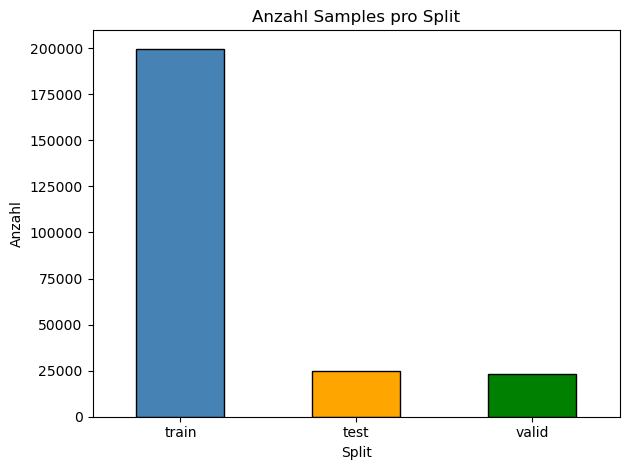

In [4]:
# Label hinzufügen für spätere Plots
test_df['split']  = 'test'
train_df['split'] = 'train'
valid_df['split'] = 'valid'

all_df = pd.concat([train_df, valid_df, test_df], ignore_index=True)

split_counts = all_df['split'].value_counts()
print(split_counts)

split_counts.plot(kind='bar', color=['steelblue', 'orange', 'green'], edgecolor='black')
plt.title('Anzahl Samples pro Split')
plt.xlabel('Split')
plt.ylabel('Anzahl')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 2. Dialektregionen

Dialektregionen im Test-Set:
dialect_region
Basel           3515
Bern            3515
Innerschweiz    3515
Ostschweiz      3515
Wallis          3515
Zürich          3515
Graubünden      3515
Name: count, dtype: int64


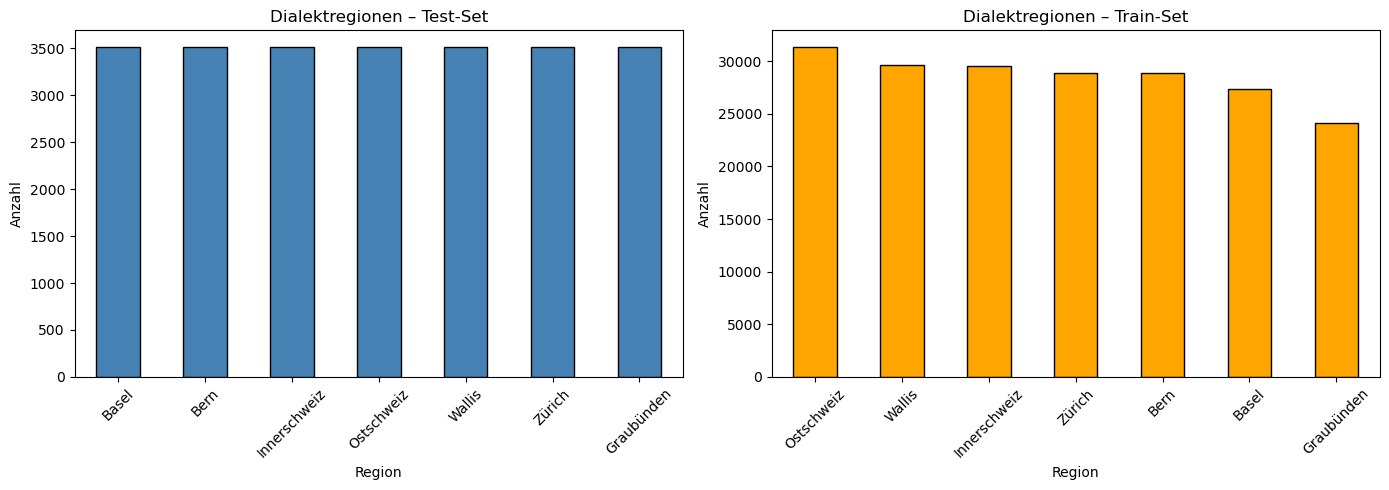

In [5]:
# Verteilung der Dialektregionen im Test-Set (wichtig für unseren WER-Vergleich)
dialect_counts = test_df['dialect_region'].value_counts()
print('Dialektregionen im Test-Set:')
print(dialect_counts)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Test-Set
test_df['dialect_region'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Dialektregionen – Test-Set')
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Anzahl')
axes[0].tick_params(axis='x', rotation=45)

# Train-Set
train_df['dialect_region'].value_counts().plot(kind='bar', ax=axes[1], color='orange', edgecolor='black')
axes[1].set_title('Dialektregionen – Train-Set')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Anzahl')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 3. Audiodauer

=== Test-Set Audiodauer (Sekunden) ===
count    24605.000000
mean         4.947893
std          1.384131
min          2.066667
25%          3.938667
50%          4.766667
75%          5.774667
max         14.558667
Name: duration, dtype: float64

Gesamtdauer Test: 33.82 Stunden
Gesamtdauer Train: 275.98 Stunden


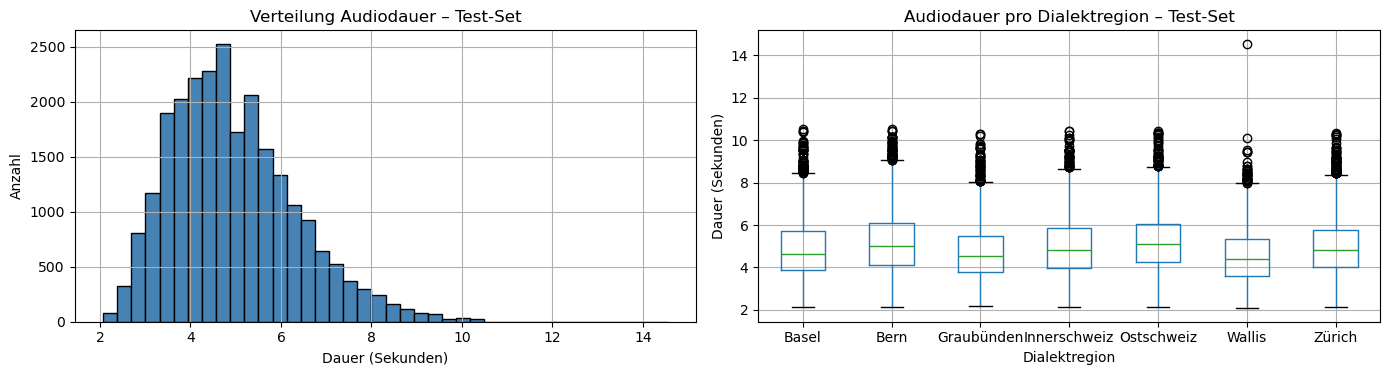

In [6]:
# Audiodauer-Statistiken
print('=== Test-Set Audiodauer (Sekunden) ===')
print(test_df['duration'].describe())
print(f'\nGesamtdauer Test: {test_df["duration"].sum() / 3600:.2f} Stunden')
print(f'Gesamtdauer Train: {train_df["duration"].sum() / 3600:.2f} Stunden')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogramm Dauer
test_df['duration'].hist(bins=40, ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Verteilung Audiodauer – Test-Set')
axes[0].set_xlabel('Dauer (Sekunden)')
axes[0].set_ylabel('Anzahl')

# Dauer pro Dialektregion (Boxplot)
test_df.boxplot(column='duration', by='dialect_region', ax=axes[1])
axes[1].set_title('Audiodauer pro Dialektregion – Test-Set')
axes[1].set_xlabel('Dialektregion')
axes[1].set_ylabel('Dauer (Sekunden)')
plt.suptitle('')  # Seaborn-Default-Titel entfernen

plt.tight_layout()
plt.show()

## 4. Demographische Daten

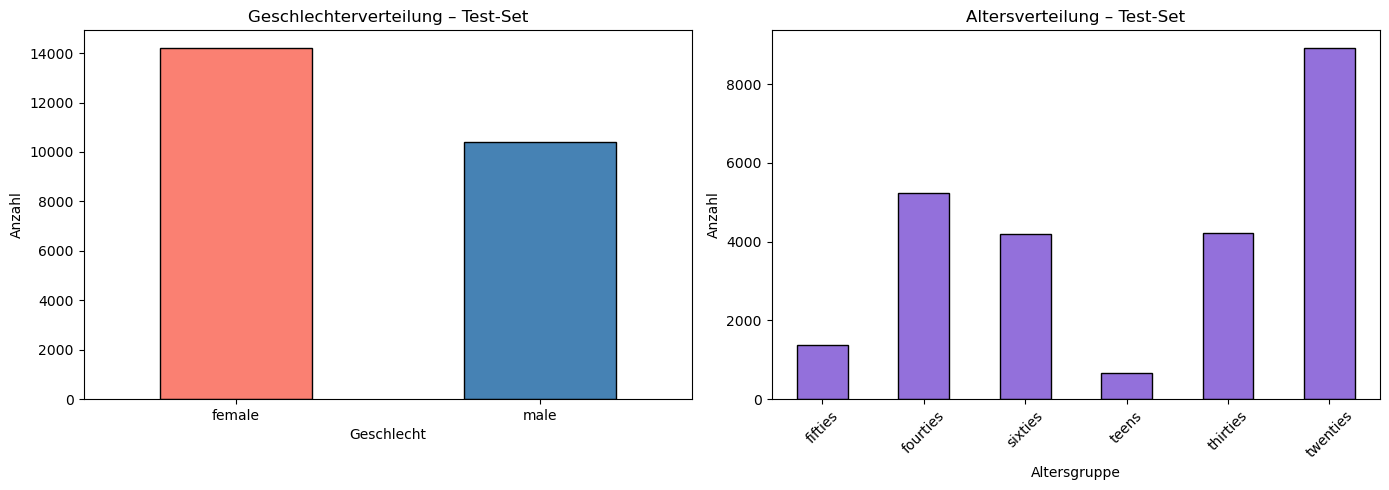

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Geschlecht
test_df['gender'].value_counts().plot(kind='bar', ax=axes[0], color=['salmon', 'steelblue'], edgecolor='black')
axes[0].set_title('Geschlechterverteilung – Test-Set')
axes[0].set_xlabel('Geschlecht')
axes[0].set_ylabel('Anzahl')
axes[0].tick_params(axis='x', rotation=0)

# Altersgruppen
test_df['age'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='mediumpurple', edgecolor='black')
axes[1].set_title('Altersverteilung – Test-Set')
axes[1].set_xlabel('Altersgruppe')
axes[1].set_ylabel('Anzahl')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

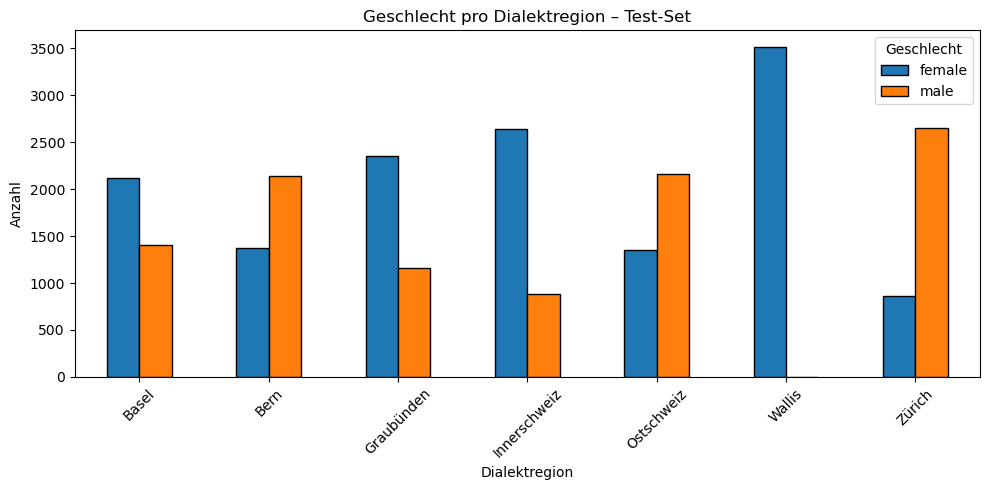

In [8]:
# Geschlecht pro Dialektregion (könnte WER beeinflussen)
gender_region = test_df.groupby(['dialect_region', 'gender']).size().unstack(fill_value=0)
gender_region.plot(kind='bar', figsize=(10, 5), edgecolor='black')
plt.title('Geschlecht pro Dialektregion – Test-Set')
plt.xlabel('Dialektregion')
plt.ylabel('Anzahl')
plt.xticks(rotation=45)
plt.legend(title='Geschlecht')
plt.tight_layout()
plt.show()

## 5. Transkript-Analyse

=== Wörter pro Transkript – Test-Set ===
count    24605.000000
mean         7.956472
std          2.094969
min          2.000000
25%          6.000000
50%          8.000000
75%         10.000000
max         12.000000
Name: word_count, dtype: float64


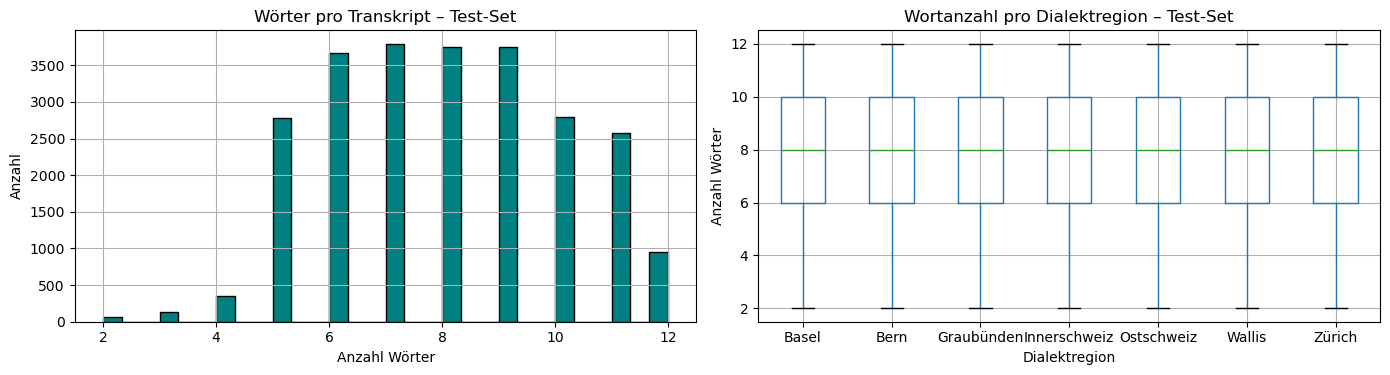

In [9]:
# Transkript-Länge (Anzahl Wörter)
test_df['word_count'] = test_df['sentence'].str.split().str.len()
train_df['word_count'] = train_df['sentence'].str.split().str.len()

print('=== Wörter pro Transkript – Test-Set ===')
print(test_df['word_count'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

test_df['word_count'].hist(bins=30, ax=axes[0], color='teal', edgecolor='black')
axes[0].set_title('Wörter pro Transkript – Test-Set')
axes[0].set_xlabel('Anzahl Wörter')
axes[0].set_ylabel('Anzahl')

# Wortanzahl pro Dialektregion
test_df.boxplot(column='word_count', by='dialect_region', ax=axes[1])
axes[1].set_title('Wortanzahl pro Dialektregion – Test-Set')
axes[1].set_xlabel('Dialektregion')
axes[1].set_ylabel('Anzahl Wörter')
plt.suptitle('')

plt.tight_layout()
plt.show()

Sentence Sources im Test-Set:
sentence_source
parliament    8071
news_switz    1848
news_cultu    1848
news_sport    1848
news_other    1841
news_every    1841
news_finan    1834
news_scien    1834
news_inter    1820
news_tech     1820
Name: count, dtype: int64


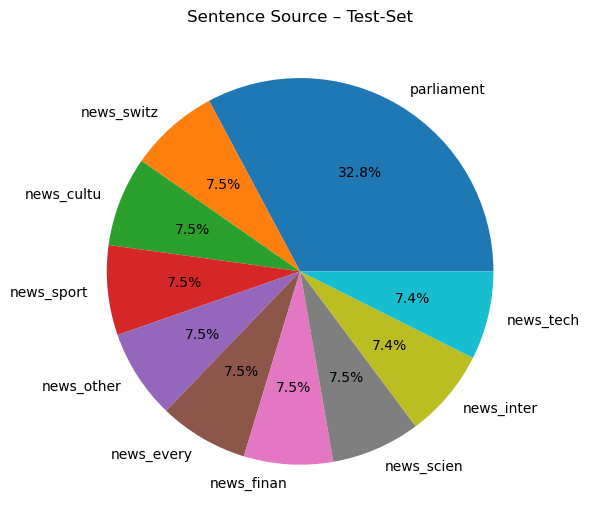

In [10]:
# Sentence Source – woher kommen die Texte?
print('Sentence Sources im Test-Set:')
print(test_df['sentence_source'].value_counts())

test_df['sentence_source'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))
plt.title('Sentence Source – Test-Set')
plt.ylabel('')
plt.tight_layout()
plt.show()

## 6. Kantone & Geografische Verteilung

Kantone im Test-Set:
canton
VS    3515
GR    3159
ZH    2532
BE    2494
SG    2450
BS    2261
LU    1704
AG    1550
BL    1254
SO     813
ZG     723
TG     721
UR     365
GL     364
TI     356
SH     344
Name: count, dtype: int64


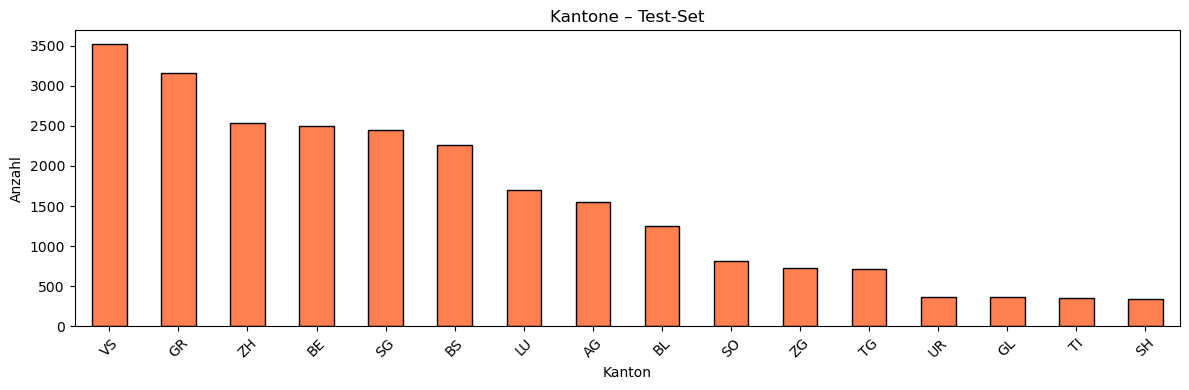

In [11]:
# Kantone im Test-Set
print('Kantone im Test-Set:')
print(test_df['canton'].value_counts())

test_df['canton'].value_counts().plot(kind='bar', figsize=(12, 4), color='coral', edgecolor='black')
plt.title('Kantone – Test-Set')
plt.xlabel('Kanton')
plt.ylabel('Anzahl')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7. Zusammenfassung für Whisper-Experiment

In [12]:
print('=== ZUSAMMENFASSUNG TEST-SET ===')
print(f'Anzahl Samples:          {len(test_df)}')
print(f'Anzahl unique Speakers:  {test_df["client_id"].nunique()}')
print(f'Dialektregionen:         {sorted(test_df["dialect_region"].unique())}')
print(f'Gesamtdauer:             {test_df["duration"].sum() / 60:.1f} Minuten')
print(f'Ø Dauer pro Sample:      {test_df["duration"].mean():.2f} Sekunden')
print(f'Ø Wörter pro Transkript: {test_df["word_count"].mean():.1f}')
print(f'\nGeschlecht:')
print(test_df['gender'].value_counts().to_string())
print(f'\nAltersgruppen:')
print(test_df['age'].value_counts().to_string())

=== ZUSAMMENFASSUNG TEST-SET ===
Anzahl Samples:          24605
Anzahl unique Speakers:  76
Dialektregionen:         ['Basel', 'Bern', 'Graubünden', 'Innerschweiz', 'Ostschweiz', 'Wallis', 'Zürich']
Gesamtdauer:             2029.0 Minuten
Ø Dauer pro Sample:      4.95 Sekunden
Ø Wörter pro Transkript: 8.0

Geschlecht:
gender
female    14211
male      10394

Altersgruppen:
age
twenties    8918
fourties    5234
thirties    4217
sixties     4193
fifties     1382
teens        661
